# Vertical integration for spatialmeta

# Loading data & Preprocessing

## Import statements

This tutorial demonstrates the process of vertically integrating spatial transcriptomics (ST) and spatial metabolomics (SM) data using spatialMETA.

In [2]:
import seaborn as sns
import spatialmeta as smt
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

## Downloading and storing data

In this section, we read and preprocess the joint SM and ST data. The steps include removing unwanted genes, normalizing the data, identifying spatial variable genes and metabolites, and selecting the subset of spatial variable genes and metaboliyes for further analysis.

In [3]:
joint_adata = sc.read_h5ad("../spatialmeta/data/datasets/adata_joint_Y7_T_raw_raw.h5ad")

Load the AnnData object for the given sample name and modality.

Parameters: <br>
**sample_name** – str The name of the sample. Use list_datasets to get the list of all available datasets. <br>
**modality** – Literal[“ST”, “SM”, “joint”] The modality of the dataset. Choose from “ST”, “SM”, or “joint”. <br>

In [4]:
joint_adata = smt.data.load_adata(
    sample_name="Y7_T_raw",
    modality="joint"
)

C:\Users\harry\Desktop\HSleiden\Jaar_3\LUMC_Xext2\spatialmeta\data\./datasets/adata_joint_Y7_T_raw_raw.h5ad


In [5]:
print(joint_adata)

AnnData object with n_obs × n_vars = 1914 × 37703
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type'
    uns: 'spatial'
    obsm: 'spatial'


## Preprocessing

removing unwanted genes (Not listed on spatialmeta docs). <br>
pp. stands for preprocessing


In [6]:
joint_adata = smt.pp.removeHSP_MT_RPL_DNAJ(joint_adata)

In [7]:
joint_adata.layers["counts"] = joint_adata.X.copy()

Normalize the total intensity of the SM and ST data in the joint AnnData object.

Parameters: <br>
**joint_adata** – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**target_sum_SM** – Optional[int]. The target sum for SM data, default is 1e4. <br>
**target_sum_ST** – Optional[int]. The target sum for ST data, default is 1e4. <br>

In [8]:
smt.pp.normalize_total_joint_adata_sm_st(joint_adata,
                         target_sum_SM=1e4,
                         target_sum_ST=1e4)

In [9]:
joint_adata.layers["normalized"] = joint_adata.X.copy()

In [10]:
joint_adata.raw = joint_adata

Calculate the spatial variables for the joint AnnData object and remove the batch-specific spatial variables.

Parameters: <br>
joint_adata – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**n_top_genes** – int. The number of top genes, default is 2000. <br>
**n_top_metabolites** – int. The number of top metabolites, default is 800. <br>
**add_key** – str. The key for the spatial variables, default is “highly_variable_moranI”. <br>
batch_key – Optional[str]. The batch key, default is None. <br>
min_samples – int. The minimum number of samples, default is 2. <br>
min_frac – float. The minimum fraction, default is 0.8. <br>
min_logfc – float. The minimum log fold change, default is 3. <br>

In [11]:
smt.pp.spatial_variable_joint_adata_sm_st(joint_adata,
                                         n_top_genes = 2000,
                                         n_top_metabolites = 800,
                                         add_key = "highly_variable_moranI")

In [12]:
joint_adata = joint_adata[:,joint_adata.var.highly_variable_moranI]

In [13]:
joint_adata.write_h5ad("../spatialmeta/data/datasets/Y7_T_adata_joint_hvf2800.h5ad")

# ConditionalVAE model for vertical integration

In this section, we train a ConditionalVAE model on the preprocessed joint SM and ST data. The VAE model learns a low-dimensional representation of the data that captures the underlying structure and relationships between the SM and ST measurements.

In [14]:
joint_adata = sc.read_h5ad("../spatialmeta/data/datasets/Y7_T_adata_joint_hvf2800.h5ad")

In [15]:
joint_adata.X = joint_adata.layers["counts"]

Normalize the total intensity of the SM and ST data in the joint AnnData object.

Parameters: <br>
**joint_adata** – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**target_sum_SM** – Optional[int]. The target sum for SM data, default is 1e4. <br>
**target_sum_ST** – Optional[int]. The target sum for ST data, default is 1e4. <br>

In [16]:
smt.pp.normalize_total_joint_adata_sm_st(
    joint_adata,
    target_sum_SM=1e3,
    target_sum_ST=None
)

This class implements a Conditional Variational Autoencoder with Mixture of Experts (MoE) for vertical and horizontal integration of ST and SM.

Parameters: <br>
adata – AnnDataJointSMST object containing the spatial multi-omics data. <br>
hidden_stacks – List of integers specifying the number of hidden units in each stack of the encoder and decoder, default is [128]. <br>
batch_keys – Optional list of strings specifying the batch keys for batch correction. <br>
n_latent – Integer specifying the dimensionality of the latent space, default is 10. <br>
bias – Boolean indicating whether to include bias terms in the linear layers, default is True. <br>
use_batch_norm – Boolean indicating whether to use batch normalization in the linear layers, default is True. <br>
use_layer_norm – Boolean indicating whether to use layer normalization in the linear layers, default is False. <br>
dropout_rate – Float specifying the dropout rate for the linear layers, default is 0.1. <br>
activation_fn – Callable specifying the activation function to use in the linear layers, default is nn.ReLU. <br>
**device** – String or torch.device specifying the device to use for computation, default is “cpu”. <br>
batch_embedding – Literal[“embedding”, “onehot”] specifying the type of batch embedding to use, default is “onehot”. <br>
encode_libsize – Boolean indicating whether to encode library size information, default is False. <br>
batch_hidden_dim – Integer specifying the dimensionality of the batch hidden layer, default is 8. <br>
**reconstruction_method_st** – Literal[‘mse’, ‘zg’, ‘zinb’] specifying the reconstruction method for the spatial data, default is ‘zinb’. <br>
**reconstruction_method_sm** – Literal[‘mse’, ‘zg’, ‘g’] specifying the reconstruction method for the single-cell multi-omics data, default is ‘g’. <br>

In [17]:
model = smt.model.ConditionalVAESTSM(
    joint_adata,
    device='cpu', # Small change to CPU instead of CUDA
    reconstruction_method_sm='g',
    reconstruction_method_st='zinb',
)

Fits the model.

Parameters: <br>
**max_epoch** – Integer specifying the maximum number of epochs to train the model, default is 35. <br>
n_per_batch – Integer specifying the number of samples per batch, default is 128. <br>
**mode** – Optional string specifying the mode of training. Can be either ‘single’ or ‘multi’, default is None. <br>
reconstruction_reduction – String specifying the reduction method for the reconstruction loss, default is ‘sum’. <br>
kl_weight – Float specifying the weight of the KL divergence loss, default is 1. <br>
reconstruction_st_weight – Float specifying the weight of the reconstruction loss for spatial transcriptomics, default is 1. <br>
reconstruction_sm_weight – Float specifying the weight of the reconstruction loss for single-cell multi-omics, default is 1. <br>
reconstruction_st_corr_weight – Float specifying the weight of the correlation reconstruction loss for spatial transcriptomics, default is 1. <br>
reconstruction_sm_corr_weight – Float specifying the weight of the correlation reconstruction loss for single-cell multi-omics, default is 1. <br>
n_epochs_kl_warmup – Integer specifying the number of epochs for KL divergence warmup, default is 400. <br>
optimizer_parameters – Iterable specifying the parameters for the optimizer, default is None. <br>
weight_decay – Float specifying the weight decay for the optimizer, default is 1e-6. <br>
**lr** – Float specifying the learning rate for the optimizer. <br>
random_seed – Integer specifying the random seed, default is 12. <br>
kl_loss_reduction – String specifying the reduction method for the KL divergence loss, default is ‘mean’. <br>
mmd_weight – Float specifying the weight of the MMD loss, default is 1. <br>

Returns: <br>
Dictionary containing the training loss values. <br>

In [18]:
loss_dict = model.fit(
    max_epoch=64,
    lr=1e-3,
    mode='single'
)

Epoch 64: 100%|██████████| 64/64 [00:41<00:00,  1.55it/s, reconst_sm=-8.67e+01, reconst_st=3.25e+02, reconst_sm_corr=-9.09e+01, reconst_st_corr=3.24e+02, kldiv=4.77e+00, total_loss=3.07e+03, mmd_loss=0.00e+00]


## Loss visualisation

In this section, we visualize the loss during the training of the ConditionalVAE model. The loss consists of three components: Kullback-Leibler divergence loss, reconstruction loss for spatial metabolomics (SM), and reconstruction loss for spatial transcriptomics (ST).

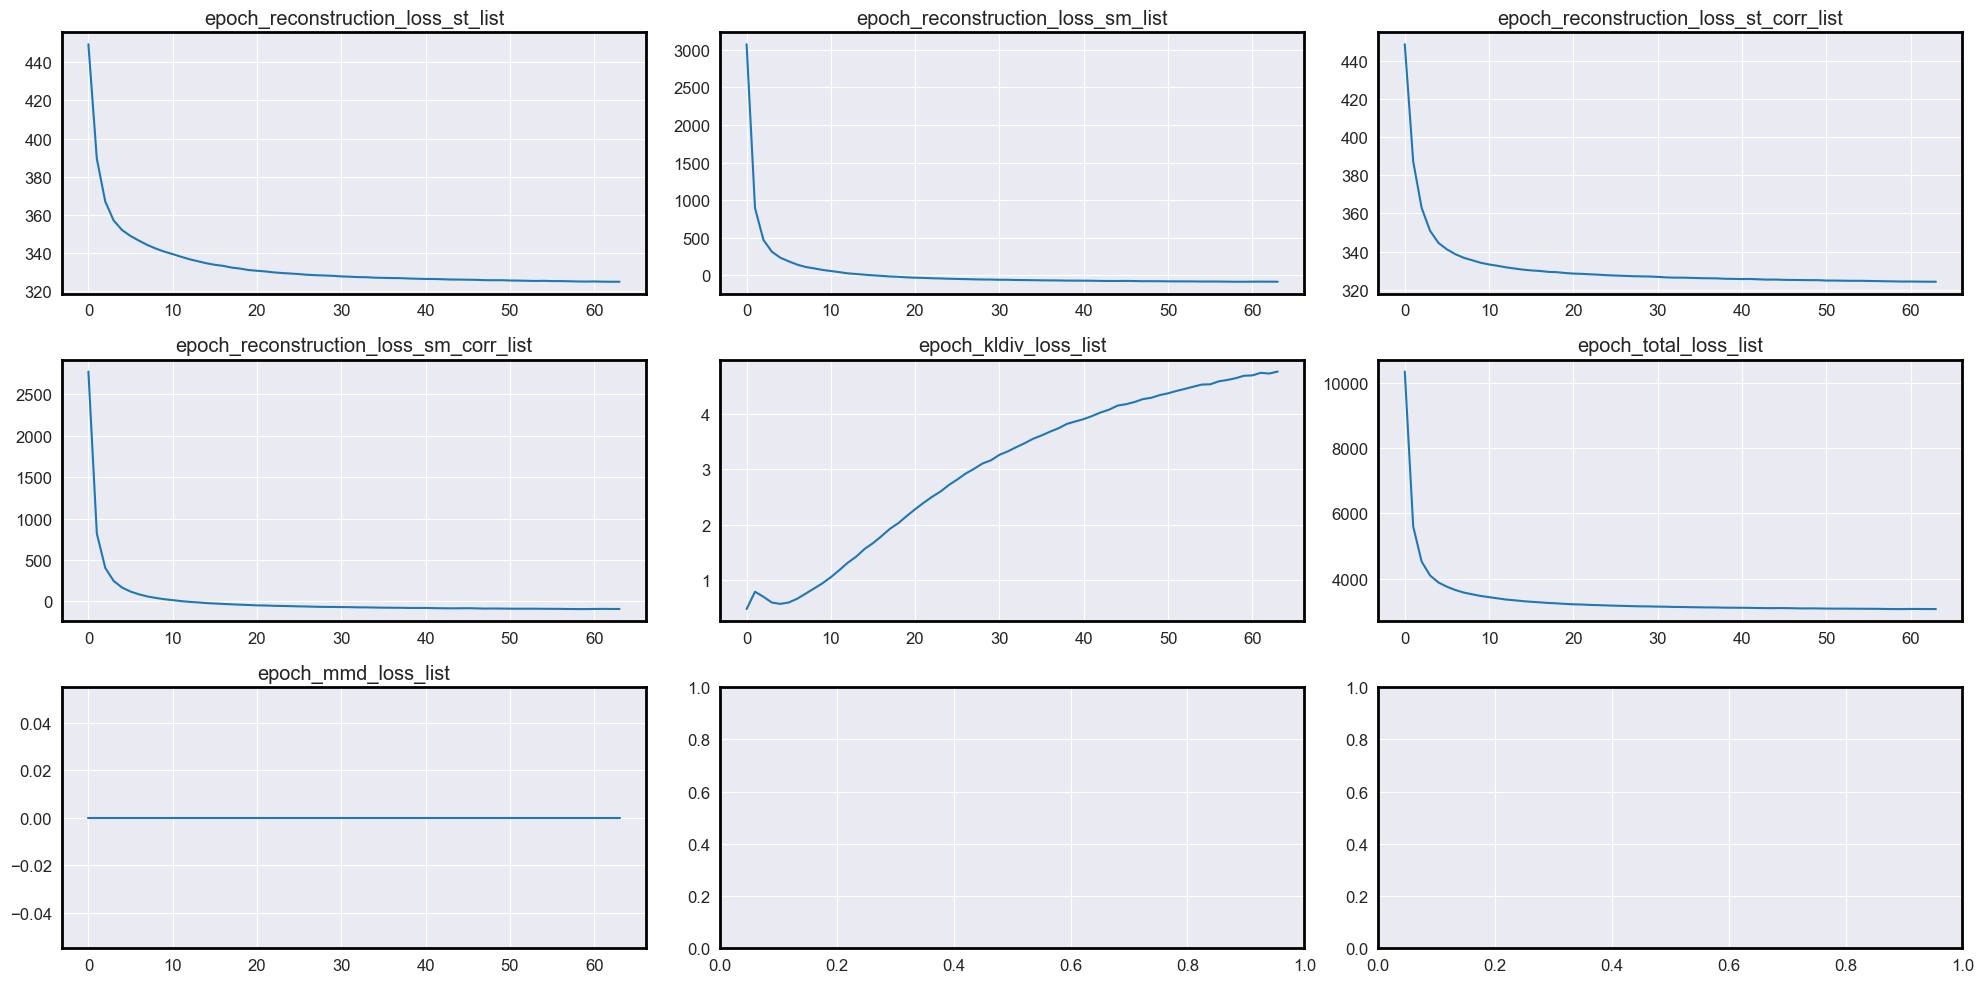

In [19]:
fig,axes = plt.subplots(3, 3, figsize=(20,10))
axes = axes.flatten()

for ax, (k, v) in zip(axes, loss_dict.items()):
    ax.plot(v)
    ax.set_title(k)

plt.tight_layout()
plt.show()

## Visualisation and analysis

In this section, we visualize the results of the vertical integration using various plots and analysis techniques. We plot the loss curves during model training, visualize the latent space using UMAP, and explore the spatial patterns of specific genes or metabolites after denoising.

In [20]:
Z = model.get_latent_embedding()
X = model.get_normalized_expression()
C = model.get_modality_contribution()

Latent Embedding: 100%|██████████| 15/15 [00:00<00:00, 203.99it/s]


In [21]:
joint_adata.layers['reconstruction'] = X
joint_adata.obsm['X_emb']=Z
joint_adata.obs['contribution_st']=C
joint_adata.obs['contribution_sm']=1-C

Compute the nearest neighbors distance matrix and a neighborhood graph of observations

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**use_rep** (str) - Use the indicated representation. 'X' or any key for .obsm is valid. <br>
**n_neighbors** (int) - The size of local neighborhood (in terms of number of neighboring data points) used for manifold approximation. Larger values result in more global views of the manifold, while smaller values result in more local data being preserved. <br>

In [ ]:
sc.pp.neighbors(
    joint_adata,
    use_rep="X_emb",
    n_neighbors=15
)

Embed the neighborhood graph using UMAP. UMAP (Uniform Manifold Approximation and Projection) is a manifold learning technique suitable for visualizing high-dimensional data.

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**min_dist** (float) - The effective minimum distance between embedded points. Smaller values will result in a more clustered/clumped embedding where nearby points on the manifold are drawn closer together, while larger values will result on a more even dispersal of points. <br>
**spread** (float) - The effective scale of embedded points. In combination with min_dist this determines how clustered/clumped the embedded points are. <br>

In [ ]:
sc.tl.umap(
    joint_adata,
    min_dist=1,
    spread=1
)

Cluster cells into subgroups. Cluster cells using the Leiden algorithm, an improved version of the Louvain algorithm.

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**key_added** (str) - (adata.obs) key under which to add the cluster labels. <br>


In [22]:
sc.tl.leiden(
    joint_adata,
    key_added="VAE_clusters_latent10"
)

In [23]:
joint_adata = sc.read_h5ad("../spatialmeta/data/datasets/Y7_T_adata_joint_hvf2800_spatialmeta.h5ad")

### Cluster plot

Scatter plot in UMAP basis.
https://scanpy.scverse.org/en/stable/api/generated/scanpy.pl.umap.html#scanpy.pl.umap

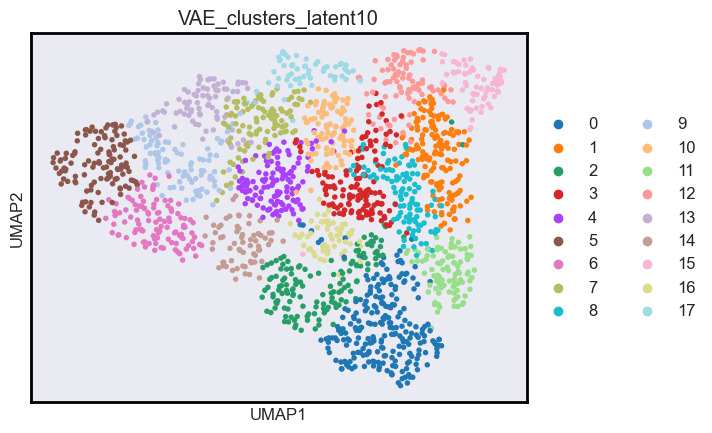

In [24]:
sc.pl.umap(
    joint_adata,
    color=["VAE_clusters_latent10"],
    show=True
)

### Hires plots

Scatter plot in spatial coordinates.
https://scanpy.scverse.org/en/stable/api/generated/scanpy.pl.spatial.html#scanpy.pl.spatial

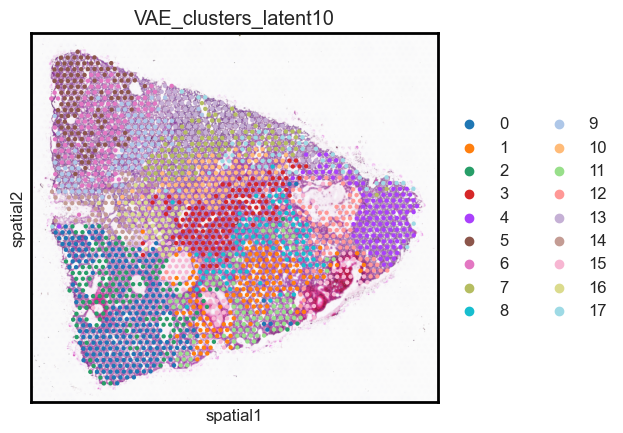

In [25]:
sc.pl.spatial(
    joint_adata,
    img_key="hires",
    color=["VAE_clusters_latent10"]
)

### Normalized plots 1 (purple)

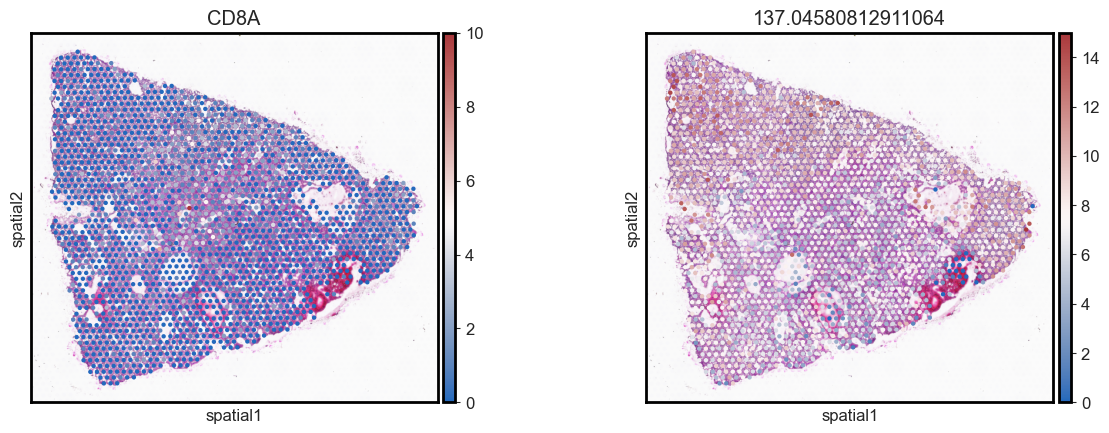

In [26]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color_map = "vlag",
              color=["CD8A","137.04580812911064"],
              layer="normalized")

### Recondstructed plots

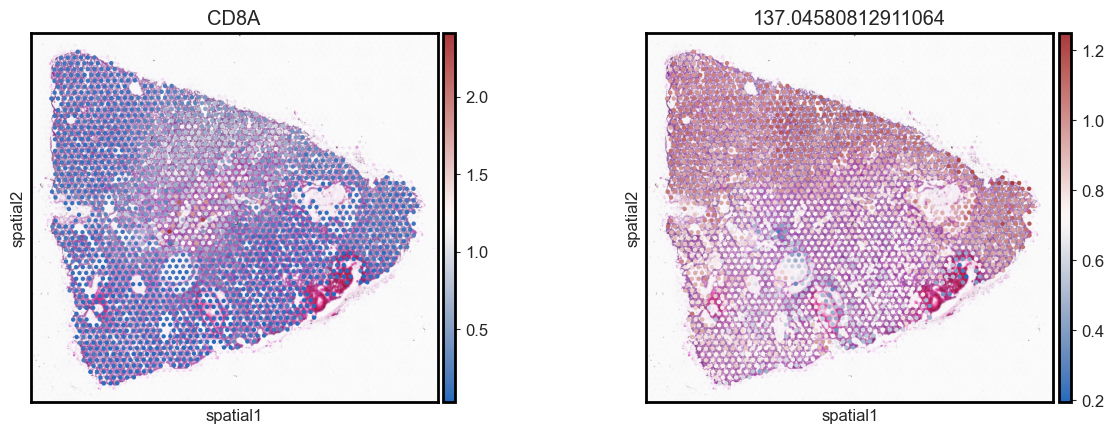

In [27]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color_map = "vlag",
              color=["CD8A","137.04580812911064"],
              layer="reconstruction")

### Normalized plots 2 (cyan)

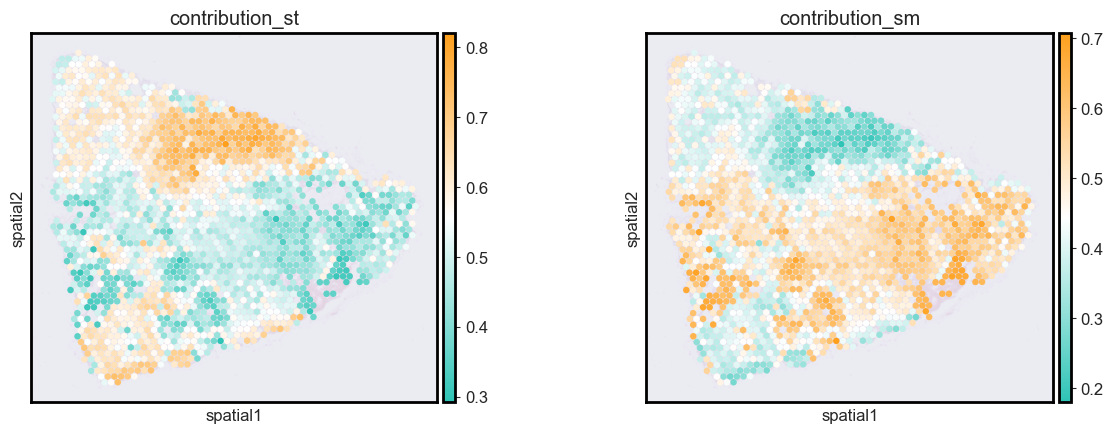

In [28]:
sc.pl.spatial(
    joint_adata,
    img_key="hires",
    color_map = smt.pl.make_colormap(['#2ec4b6','#ffffff','#ff9f1c' ]),
    color=['contribution_st','contribution_sm'],
    layer="normalized",
    alpha_img=0.1,
    size=1.5
)

### Violin plots

Create a figure with the specified size and axis properties.

Parameters: <br>
**figsize** – tuple specifying the size of the figure, default is (8, 4). <br>

Returns: <br>
figure and axis objects. <br>

A violin plot plays a similar role as a box-and-whisker plot. It shows the distribution of data points after grouping by one (or more) variables. Unlike a box plot, each violin is drawn using a kernel density estimate of the underlying distribution. <br>
https://seaborn.pydata.org/generated/seaborn.violinplot.html

In [ ]:
obs_df = joint_adata.obs
obs_filter_df = pd.concat([
    obs_df[['VAE_clusters_latent10', 'contribution_st']].rename(columns={'contribution_st': 'contribution'}).assign(type='st'),
    obs_df[['VAE_clusters_latent10', 'contribution_sm']].rename(columns={'contribution_sm': 'contribution'}).assign(type='sm')
])
fig,ax = smt.pl.create_fig(
    figsize = (12,4)
)
sns.violinplot(
    data=obs_filter_df,
    x="VAE_clusters_latent10",
    y="contribution",
    hue="type",
    split=True,
    inner="quart",
    palette=['#2ec4b6', '#FFCC70'],
    scale='width',  # Make violins the same width
    bw=0.2,         # Adjust smoothness (lower value = fatter violins)
    cut=0           # Limit the violin to data range
)

plt.xticks(rotation=90)
plt.show()

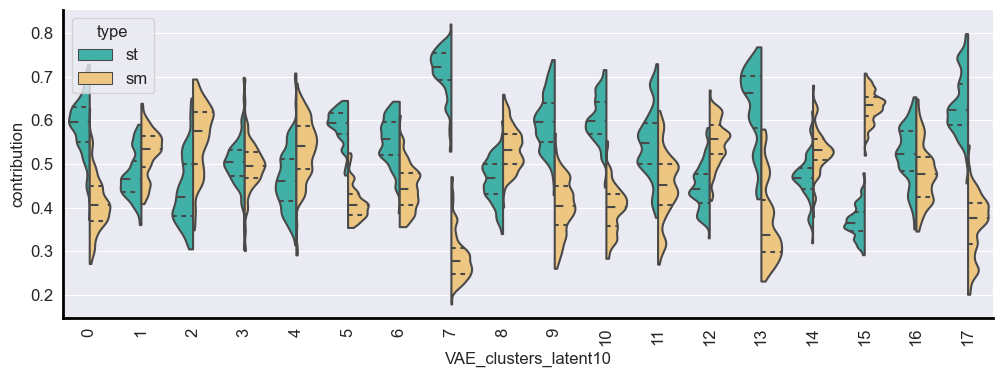

In [29]:
joint_adata.write_h5ad("../spatialmeta/data/datasets/Y7_T_adata_joint_hvf2800_spatialmeta.h5ad")